# CP1 — BNP Paribas Cardif Claims Management

In [1]:
from pathlib import Path
import pickle
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
VAL_PART = 0.15
TEST_PART = 0.15
PCA_N = 50
MAX_ITER = 1000
TOP_MISS = 20
TOP_VAR = 10
TOP_CORR = 20
HIST_N = 5
BOX_N = 4
MISS_LABEL = 'missing'

if (Path.cwd() / 'data' / 'raw' / 'train.csv').exists():
    root = Path.cwd()
elif (Path.cwd().parent / 'data' / 'raw' / 'train.csv').exists():
    root = Path.cwd().parent
elif (Path.cwd() / 'train.csv').exists():
    root = Path.cwd()
elif (Path.cwd().parent / 'train.csv').exists():
    root = Path.cwd().parent
else:
    raise FileNotFoundError('train.csv не найден ни в data/raw, ни в корне проекта')

raw_dir = root / 'data' / 'raw'
if (raw_dir / 'train.csv').exists() and (raw_dir / 'test.csv').exists():
    train_path = raw_dir / 'train.csv'
    test_path = raw_dir / 'test.csv'
else:
    train_path = root / 'train.csv'
    test_path = root / 'test.csv'

out_dir = root / 'data' / 'processed'
out_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

## 1. Обработка и подготовка данных

### 1.1 Загрузка и первичный осмотр

In [2]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print('train:', train.shape)
print('test:', test.shape)
display(train.dtypes.value_counts())
display(train.head())
display(train.describe(include='all').T.head(20))

id_col = 'id' if 'id' in train.columns else 'ID'
feat = [c for c in train.columns if c not in [id_col, 'target']]
num_cols = train[feat].select_dtypes(include=['number']).columns.tolist()
cat_cols = train[feat].select_dtypes(exclude=['number']).columns.tolist()

print('id column:', id_col)
print('numeric:', len(num_cols))
print('categorical:', len(cat_cols))

train: (114321, 133)
test: (114393, 132)


float64    108
str         19
int64        6
Name: count, dtype: int64

,ID,target,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,v11,v12,v13,v14,v15,v16,v17,v18,v19,v20,v21,v22,v23,v24,v25,v26,v27,v28,v29,v30,v31,v32,v33,v34,v35,v36,v37,v38,v39,v40,v41,v42,v43,v44,v45,v46,v47,v48,v49,v50,v51,v52,v53,v54,v55,v56,v57,v58,v59,v60,v61,v62,v63,v64,v65,v66,v67,v68,v69,v70,v71,v72,v73,v74,v75,v76,v77,v78,v79,v80,v81,v82,v83,v84,v85,v86,v87,v88,v89,v90,v91,v92,v93,v94,v95,v96,v97,v98,v99,v100,v101,v102,v103,v104,v105,v106,v107,v108,v109,v110,v111,v112,v113,v114,v115,v116,v117,v118,v119,v120,v121,v122,v123,v124,v125,v126,v127,v128,v129,v130,v131
0,3,1,1.335739,8.727474,C,3.921026,7.915266,2.599278,3.176895,0.012941,9.999999,0.503281,16.434108,6.085711,2.866830,11.636387,1.355013,8.571429,3.670350,0.106720,0.148883,18.869283,7.730923,XDX,-1.716131e-08,C,0.139412,1.720818,3.393503,0.590122,8.880867,C,A,1.083033,1.010829,7.270147,8.375452,11.326592,0.454546,0,4.012088,7.711453,7.653429,12.707581,2.015505,10.498338,9.848672,0.113561,C,12.171733,8.086643,0.899420,7.277792,G,16.747968,0.037096,1.299638,DI,3.971118,0.529802,10.890984,1.588448,15.858152,1,0.153461,6.363189,18.303925,C,9.314079,15.231789,17.142857,11.784549,F,1,1.614988,B,D,2.230940,7.292418,8.571429,E,3.000000,7.528326,8.861647,0.649820,1.299638,1.707317,0.866426,9.551836,3.321300,0.095678,0.905342,A,0.442252,5.814018,3.517720,0.462019,7.436824,5.454545,8.877414,1.191337,19.470199,8.389237,2.757375,4.374296,1.574039,0.007294,12.579184,E,2.382692,3.930922,B,0.433213,O,NaN,15.634907,2.857144,1.951220,6.592012,5.909091,-6.297423e-07,1.059603,0.803572,8.000000,1.989780,0.035754,AU,1.804126,3.113719,2.024285,0,0.636365,2.857144
1,4,1,NaN,NaN,C,NaN,9.191265,NaN,NaN,2.301630,NaN,1.312910,NaN,6.507647,NaN,11.636386,NaN,NaN,NaN,NaN,NaN,NaN,6.763110,GUV,NaN,C,3.056144,NaN,NaN,NaN,NaN,C,A,NaN,NaN,3.615077,NaN,14.579479,NaN,0,NaN,14.305766,NaN,NaN,NaN,NaN,NaN,2.449959,E,NaN,NaN,1.379210,NaN,G,NaN,1.129469,NaN,DY,NaN,NaN,NaN,NaN,NaN,2,2.544736,NaN,NaN,A,NaN,NaN,NaN,12.053353,F,2,NaN,B,D,NaN,NaN,NaN,D,NaN,7.277655,3.430691,NaN,NaN,NaN,NaN,9.848004,NaN,2.678584,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,8.303967,NaN,NaN,NaN,NaN,NaN,NaN,1.505335,NaN,B,1.825361,4.247858,A,NaN,U,G,10.308044,NaN,NaN,10.595357,NaN,NaN,NaN,NaN,NaN,NaN,0.598896,AF,NaN,NaN,1.957825,0,NaN,NaN
2,5,1,0.943877,5.310079,C,4.410969,5.326159,3.979592,3.928571,0.019645,12.666667,0.765864,14.756098,6.384670,2.505589,9.603542,1.984127,5.882353,3.170847,0.244541,0.144258,17.952332,5.245035,FQ,-2.785053e-07,E,0.113997,2.244897,5.306122,0.836005,7.499999,NaN,A,1.454082,1.734693,4.043864,7.959184,12.730517,0.259740,0,7.378964,13.077201,6.173469,12.346939,2.926830,8.897561,5.343819,0.126035,C,12.711328,6.836734,0.604504,9.637627,F,15.102041,0.085573,0.765305,AS,4.030613,4.277456,9.105481,2.151361,16.075602,1,0.123643,5.517949,16.377205,A,8.367347,11.040463,5.882353,8.460654,B,3,2.413618,B,B,1.963971,5.918368,11.764705,E,3.333334,10.194433,8.266200,1.530611,1.530613,2.429906,1.071429,8.447465,3.367346,0.111388,0.811447,G,0.271480,5.156559,4.214944,0.309657,5.663265,5.974026,11.588858,0.841837,15.491329,5.879353,3.292788,5.924457,1.668401,0.008275,11.670572,C,1.375753,1.184211,B,3.367348,S,NaN,11.205561,12.941177,3.129253,3.478911,6.233767,-2.792745e-07,2.138728,2.238806,9.333333,2.477596,0.013452,AE,1.773709,3.922193,1.120468,2,0.883118,1.176472
3,6,1,0.797415,8.304757,C,4.225930,11.627438,2.097700,1.987549,0.171947,8.965516,6.542669,16.347483,9.646653,3.903302,14.094723,1.945044,5.517242,3.610789,1.224114,0.231630,18.376407,7.517125,ACUE,-4.805344e-07,D,0.148843,1.308269,2.303640,8.926662,8.874521,C,B,1.587644,1.666667,8.703550,8.898468,11.302795,0.433735,0,0.287322,11.523045,7.931035,12.935823,1.470878,12.708574,9.670823,0.108387,C,12.194855,8.591954,3.329176,4.780357,H,16.621695,0.139721,1.178161,BW,3.965517,1.732102,11.777912,1.229246,15.927390,1,0.140260,6.292979,17.011645,A,9.703065,18.568129,9.425288,13.594728,F,2,2.272541,B,D,2.188198,8.213602,13.448277,B,1.947261,4.797873,13.315819,1.681034,1.379310,1.587045,1.242817,10.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,114321.0,NaN,NaN,NaN,114228.928228,65934.487362,3.0,57280.0,114189.0,171206.0,228713.0
target,114321.0,NaN,NaN,NaN,0.761199,0.426353,0.0,1.0,1.0,1.0,1.0
v1,64489.0,NaN,NaN,NaN,1.630686,1.082813,-0.000001,0.91358,1.46955,2.136128,20.000001
v2,64525.0,NaN,NaN,NaN,7.464411,2.961676,-0.000001,5.316428,7.023803,9.465497,20.0
v3,110864,3,C,110584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
v4,64525.0,NaN,NaN,NaN,4.145098,1.148263,-0.000001,3.487398,4.205991,4.83325,20.0
v5,65697.0,NaN,NaN,NaN,8.742359,2.036018,-0.000001,7.605918,8.670867,9.771353,20.0
v6,64489.0,NaN,NaN,NaN,2.436402,0.599965,-0.000001,2.065064,2.41279,2.775285,20.000001
v7,64489.0,NaN,NaN,NaN,2.483921,0.589449,-0.000001,2.101477,2.452166,2.834285,20.0
v8,65702.0,NaN,NaN,NaN,1.496569,2.783003,-0.000001,0.08659,0.386032,1.625246,20.000001


id column: ID
numeric: 112
categorical: 19


### 1.2 Пропуски

,feature,missing_percent
0,v30,52.580016
1,v113,48.376064
2,v102,44.887641
3,v85,44.333062
4,v119,44.331313
5,v51,44.329563
6,v123,44.329563
7,v23,44.326939
8,v69,43.644650
9,v78,43.644650


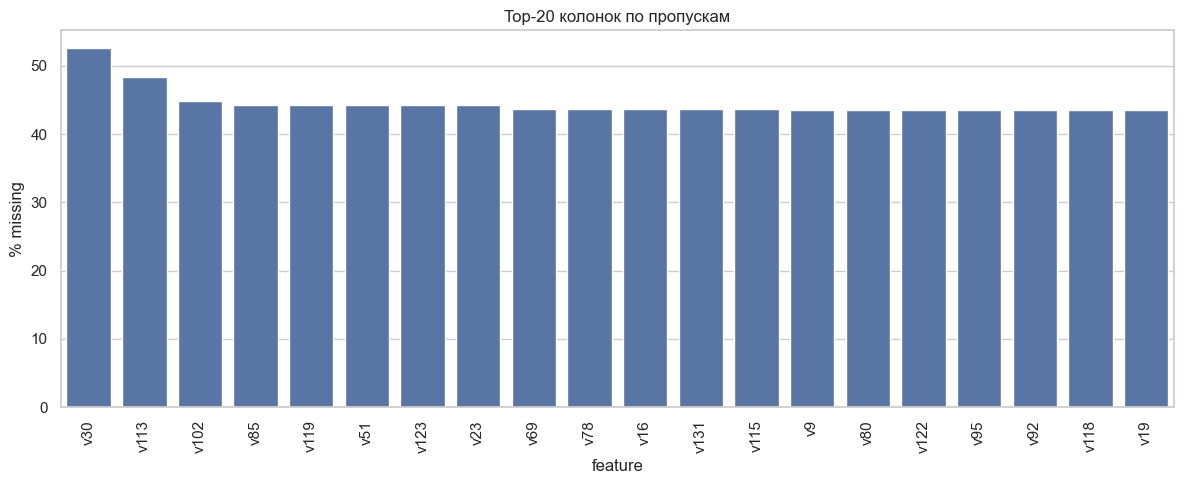

shape train после fillna: (114321, 133)
shape test после fillna: (114393, 132)
пропуски train: 0
пропуски test: 0


In [3]:
miss = train.isna().mean().mul(100).sort_values(ascending=False)
miss_df = miss.reset_index()
miss_df.columns = ['feature', 'missing_percent']
display(miss_df.head(TOP_MISS))

plt.figure(figsize=(12, 5))
sns.barplot(data=miss_df.head(TOP_MISS), x='feature', y='missing_percent')
plt.title('Top-20 колонок по пропускам')
plt.xlabel('feature')
plt.ylabel('% missing')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

train_raw = train.copy()
test_raw = test.copy()
train_f = train.copy()
test_f = test.copy()

med = train_f[num_cols].median()
train_f[num_cols] = train_f[num_cols].fillna(med)
test_f[num_cols] = test_f[num_cols].fillna(med)

for c in cat_cols:
    train_f[c] = train_f[c].fillna(MISS_LABEL)
    test_f[c] = test_f[c].fillna(MISS_LABEL)

print('shape train после fillna:', train_f.shape)
print('shape test после fillna:', test_f.shape)
print('пропуски train:', int(train_f.isna().sum().sum()))
print('пропуски test:', int(test_f.isna().sum().sum()))

### 1.3 Очистка данных

дубли id train: 0
дубли id test: 0
shape train после дублей: (114321, 133)
shape test после дублей: (114393, 132)


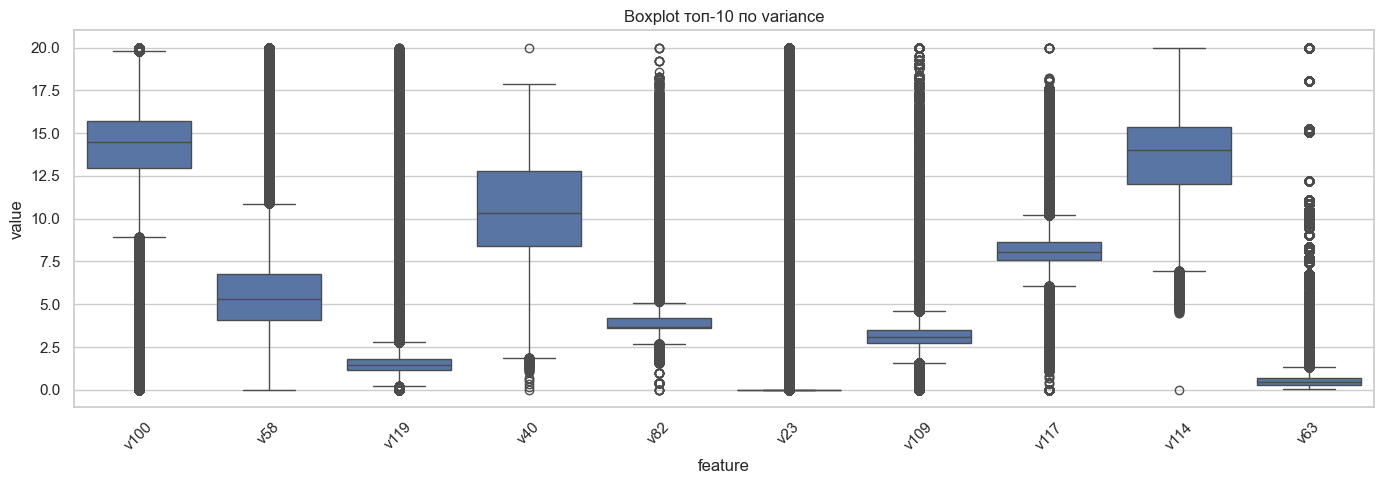

In [4]:
dup_train = train.duplicated(subset=[id_col]).sum()
dup_test = test.duplicated(subset=[id_col]).sum()
print('дубли id train:', dup_train)
print('дубли id test:', dup_test)

m_train = ~train.duplicated(subset=[id_col])
m_test = ~test.duplicated(subset=[id_col])

train = train.loc[m_train].reset_index(drop=True)
test = test.loc[m_test].reset_index(drop=True)
train_f = train_f.loc[m_train].reset_index(drop=True)
test_f = test_f.loc[m_test].reset_index(drop=True)
train_raw = train_raw.loc[m_train].reset_index(drop=True)
test_raw = test_raw.loc[m_test].reset_index(drop=True)

for c in cat_cols:
    train_f[c] = train_f[c].astype('category')
    test_f[c] = test_f[c].astype('category')

print('shape train после дублей:', train_f.shape)
print('shape test после дублей:', test_f.shape)

top_var_cols = train_f[num_cols].var().sort_values(ascending=False).head(TOP_VAR).index.tolist()
tmp = train_f[top_var_cols].melt(var_name='feature', value_name='value')

plt.figure(figsize=(14, 5))
sns.boxplot(data=tmp, x='feature', y='value')
plt.title('Boxplot топ-10 по variance')
plt.xlabel('feature')
plt.ylabel('value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 1.4 Feature Engineering

In [5]:
y = train_f['target'].copy()

x_base_train = train_f[feat].copy()
x_base_test = test_f[feat].copy()

encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    both = pd.concat([x_base_train[c], x_base_test[c]], axis=0).astype(str)
    le.fit(both)
    x_base_train[c] = le.transform(x_base_train[c].astype(str))
    x_base_test[c] = le.transform(x_base_test[c].astype(str))
    encoders[c] = le

x_fe_train = x_base_train.copy()
x_fe_test = x_base_test.copy()

x_fe_train['count_nan_per_row'] = train_raw[feat].isna().sum(axis=1)
x_fe_test['count_nan_per_row'] = test_raw[feat].isna().sum(axis=1)

x_fe_train['count_cat_per_row'] = train_raw[cat_cols].notna().sum(axis=1)
x_fe_test['count_cat_per_row'] = test_raw[cat_cols].notna().sum(axis=1)

x_fe_train['row_num_mean'] = train_f[num_cols].mean(axis=1)
x_fe_test['row_num_mean'] = test_f[num_cols].mean(axis=1)
x_fe_train['row_num_std'] = train_f[num_cols].std(axis=1)
x_fe_test['row_num_std'] = test_f[num_cols].std(axis=1)
x_fe_train['row_num_min'] = train_f[num_cols].min(axis=1)
x_fe_test['row_num_min'] = test_f[num_cols].min(axis=1)
x_fe_train['row_num_max'] = train_f[num_cols].max(axis=1)
x_fe_test['row_num_max'] = test_f[num_cols].max(axis=1)

added = ['count_nan_per_row', 'count_cat_per_row', 'row_num_mean', 'row_num_std', 'row_num_min', 'row_num_max']
print('было фичей:', len(feat))
print('добавили:', len(added))
print('стало фичей:', x_fe_train.shape[1])
print('shape x_fe_train:', x_fe_train.shape)
print('shape x_fe_test:', x_fe_test.shape)

было фичей: 131
добавили: 6
стало фичей: 137
shape x_fe_train: (114321, 137)
shape x_fe_test: (114393, 137)


### 1.5 Визуализации

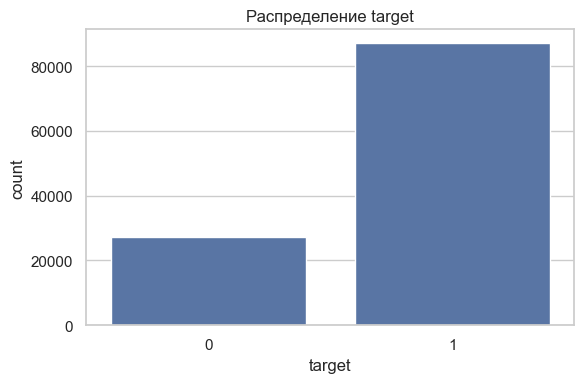

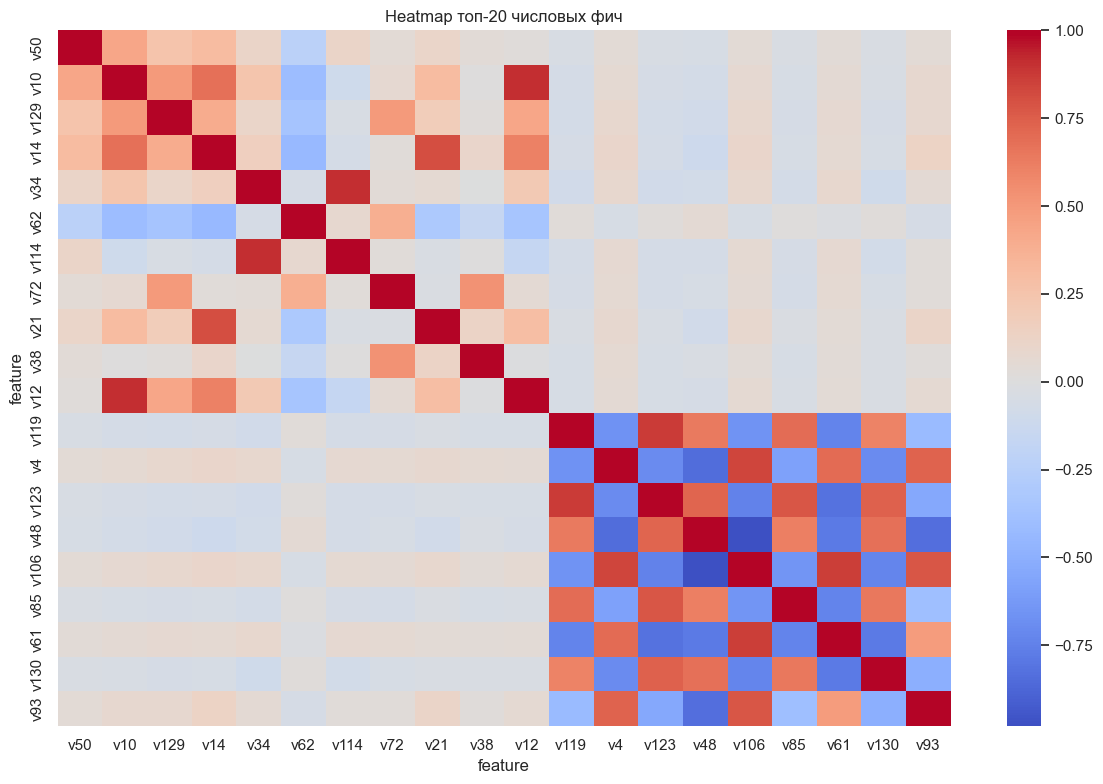

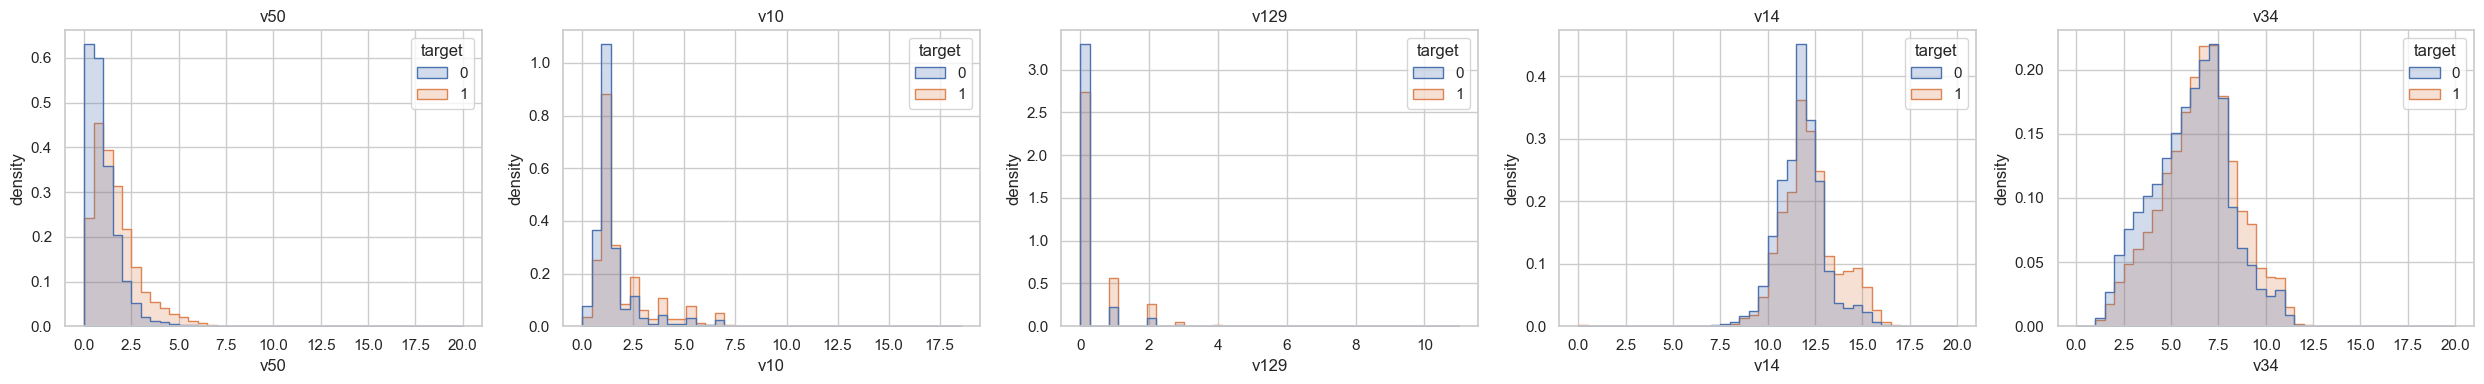

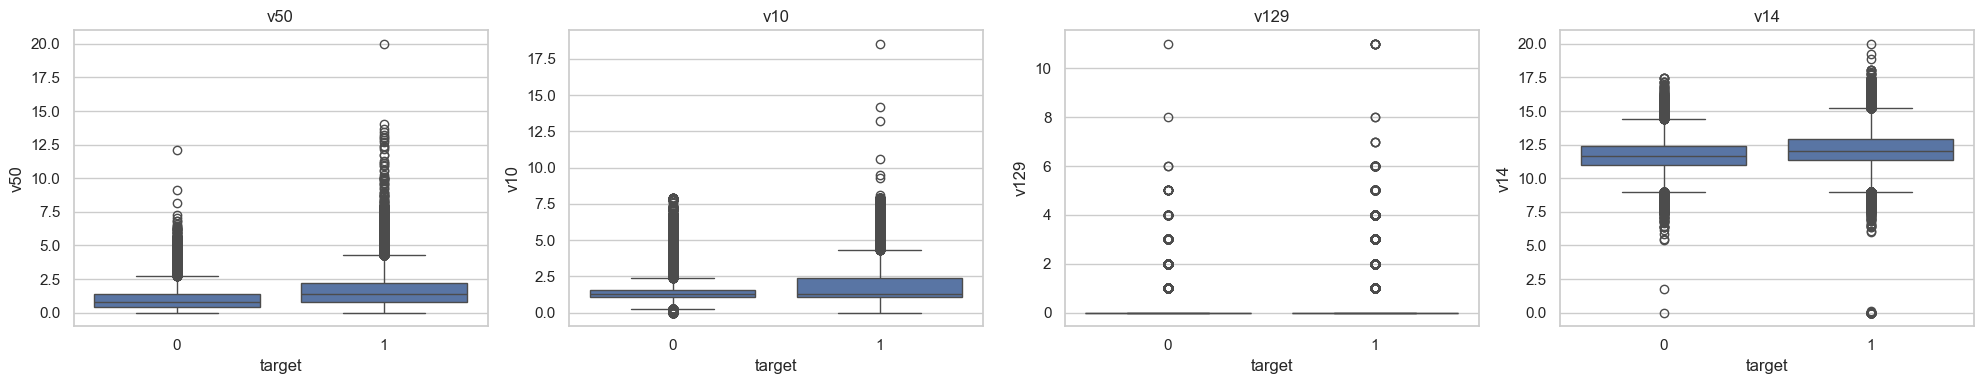

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_f, x='target')
plt.title('Распределение target')
plt.xlabel('target')
plt.ylabel('count')
plt.tight_layout()
plt.show()

corr_target = train_f[num_cols + ['target']].corr()['target'].abs().sort_values(ascending=False)
corr_cols = [c for c in corr_target.index if c != 'target'][:TOP_CORR]

plt.figure(figsize=(12, 8))
sns.heatmap(train_f[corr_cols].corr(), cmap='coolwarm', center=0)
plt.title('Heatmap топ-20 числовых фич')
plt.xlabel('feature')
plt.ylabel('feature')
plt.tight_layout()
plt.show()

hcols = corr_cols[:HIST_N]
fig, axes = plt.subplots(1, HIST_N, figsize=(5 * HIST_N, 4))
for ax, c in zip(axes, hcols):
    sns.histplot(data=train_f, x=c, hue='target', bins=40, stat='density', common_norm=False, element='step', ax=ax)
    ax.set_title(c)
    ax.set_xlabel(c)
    ax.set_ylabel('density')
plt.tight_layout()
plt.show()

bcols = corr_cols[:BOX_N]
fig, axes = plt.subplots(1, BOX_N, figsize=(5 * BOX_N, 4))
for ax, c in zip(axes, bcols):
    sns.boxplot(data=train_f, x='target', y=c, ax=ax)
    ax.set_title(c)
    ax.set_xlabel('target')
    ax.set_ylabel(c)
plt.tight_layout()
plt.show()

### 1.6 Сплит и 1.7 Метрики

In [7]:
idx = x_fe_train.index
tmp_part = VAL_PART + TEST_PART

idx_train, idx_tmp, y_train, y_tmp = train_test_split(
    idx, y, test_size=tmp_part, random_state=RANDOM_STATE, stratify=y
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_tmp
)

X_train = x_fe_train.loc[idx_train].reset_index(drop=True)
X_val = x_fe_train.loc[idx_val].reset_index(drop=True)
X_test = x_fe_train.loc[idx_test].reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

X_train_base = x_base_train.loc[idx_train].reset_index(drop=True)
X_val_base = x_base_train.loc[idx_val].reset_index(drop=True)
X_test_base = x_base_train.loc[idx_test].reset_index(drop=True)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:', X_val.shape, 'y_val:', y_val.shape)
print('X_test:', X_test.shape, 'y_test:', y_test.shape)

X_train: (80024, 137) y_train: (80024,)
X_val: (17148, 137) y_val: (17148,)
X_test: (17149, 137) y_test: (17149,)


## 2. Моделирование и эксперименты

### 2.1 Baseline: LogisticRegression без feature engineering

In [8]:
base_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=MAX_ITER)
base_model.fit(X_train_base, y_train)
p_base = base_model.predict_proba(X_val_base)[:, 1]

base_logloss = log_loss(y_val, p_base)
base_auc = roc_auc_score(y_val, p_base)

print('Baseline LogLoss:', round(base_logloss, 6))
print('Baseline ROC-AUC:', round(base_auc, 6))

Baseline LogLoss: 0.497603
Baseline ROC-AUC: 0.714763


### 2.2 Сравнение 5 моделей

In [9]:
def run_model(name, model, x_tr, y_tr, x_va, y_va):
    t0 = time.perf_counter()
    model.fit(x_tr, y_tr)
    fit_s = time.perf_counter() - t0
    p = model.predict_proba(x_va)[:, 1]
    return {
        'Model': name,
        'LogLoss (val)': log_loss(y_va, p),
        'ROC-AUC (val)': roc_auc_score(y_va, p),
        'Fit time (s)': fit_s,
    }

models = {
    'LogisticRegression': LogisticRegression(random_state=RANDOM_STATE, max_iter=MAX_ITER),
    'DecisionTreeClassifier': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RandomForestClassifier': RandomForestClassifier(random_state=RANDOM_STATE),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1),
}

rows = []
for n, m in models.items():
    rows.append(run_model(n, m, X_train, y_train, X_val, y_val))

res = pd.DataFrame(rows).sort_values('LogLoss (val)').reset_index(drop=True)
display(res)

,Model,LogLoss (val),ROC-AUC (val),Fit time (s)
0,LightGBM,0.472561,0.746681,1.401874
1,GradientBoostingClassifier,0.477184,0.739894,118.558969
2,RandomForestClassifier,0.484564,0.731297,36.230409
3,LogisticRegression,0.498149,0.712473,5.579129
4,DecisionTreeClassifier,11.323021,0.586676,6.855698


### 2.3 PCA (50 компонент) + LogisticRegression

,Model,LogLoss (val),ROC-AUC (val)
0,LogisticRegression baseline,0.497603,0.714763
1,LogisticRegression + PCA (50),0.496805,0.715480


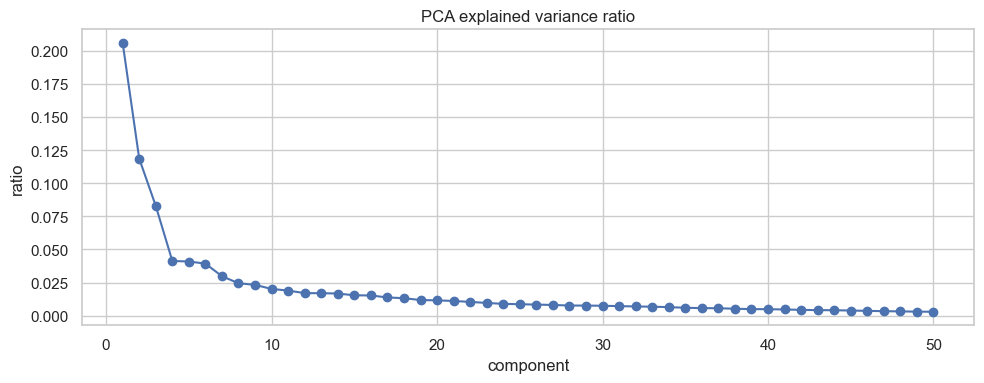

PCA лучше baseline по LogLoss: True


In [10]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=PCA_N, random_state=RANDOM_STATE)),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=MAX_ITER)),
])

pipe.fit(X_train_base, y_train)
p_pca = pipe.predict_proba(X_val_base)[:, 1]

pca_logloss = log_loss(y_val, p_pca)
pca_auc = roc_auc_score(y_val, p_pca)

cmp = pd.DataFrame([
    {'Model': 'LogisticRegression baseline', 'LogLoss (val)': base_logloss, 'ROC-AUC (val)': base_auc},
    {'Model': f'LogisticRegression + PCA ({PCA_N})', 'LogLoss (val)': pca_logloss, 'ROC-AUC (val)': pca_auc},
])
display(cmp)

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train_base)
pca_plot = PCA(n_components=PCA_N, random_state=RANDOM_STATE)
pca_plot.fit(X_train_scaled)
vr = pca_plot.explained_variance_ratio_

plt.figure(figsize=(10, 4))
plt.plot(np.arange(1, PCA_N + 1), vr, marker='o')
plt.title('PCA explained variance ratio')
plt.xlabel('component')
plt.ylabel('ratio')
plt.tight_layout()
plt.show()

print('PCA лучше baseline по LogLoss:', pca_logloss < base_logloss)

## 3. Воспроизводимость

Сохраняем подготовленные выборки в `data/`.

In [11]:
splits = {
    'X_train': X_train,
    'X_val': X_val,
    'X_test': X_test,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
}

save_path = out_dir / 'processed_splits.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(splits, f)

print('saved:', save_path)
print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test.shape)

saved: /Users/kaosintsev/Desktop/ml_project/data/processed/processed_splits.pkl
X_train: (80024, 137)
X_val: (17148, 137)
X_test: (17149, 137)
